# Stage 1 NPE Diagnostic

In [1]:
import numpy as np
import torch
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

torch_device = "cpu"

In [2]:
def SBC_KStest(ranks, num_posterior_samples, parameter_labels):
    num_dimensions = ranks.shape[1] 

    ks_results = []
    p_values = []
    for dim in range(num_dimensions):
        normalized_ranks = ranks[:, dim] / num_posterior_samples
        ks_stat, p_value = stats.kstest(normalized_ranks, 'uniform')
        ks_results.append(ks_stat)
        p_values.append(p_value)
    
    return ks_results, p_values


def multidim_coverage95(theta_est_post, theta_test_numpy):
    num_test_samples = theta_test_numpy.shape[0]
    joint_covered_count = 0

    for i in range(num_test_samples):
        samples = theta_est_post[i]  # Shape: (1000, 3)
        truth = theta_test_numpy[i]  # Shape: (3,)

        mean_vec = np.mean(samples, axis=0)
        cov_matrix = np.cov(samples, rowvar=False)
        
        try:
            inv_cov = np.linalg.inv(cov_matrix)
        except np.linalg.LinAlgError:
            print(f"Warning: Singular covariance matrix at index {i}, skipping.")
            continue

        diff_samples = samples - mean_vec
        dist_samples = np.sum(np.dot(diff_samples, inv_cov) * diff_samples, axis=1)

        diff_truth = truth - mean_vec
        dist_truth = np.dot(np.dot(diff_truth, inv_cov), diff_truth)

        threshold_95 = np.percentile(dist_samples, 95)

        if dist_truth <= threshold_95:
            joint_covered_count += 1

    joint_coverage_95 = joint_covered_count / num_test_samples

    return joint_coverage_95


def marginal_coverage95(theta_est_post, theta_test_numpy):
    lower_bounds = np.percentile(theta_est_post, 2.5, axis=1)
    upper_bounds = np.percentile(theta_est_post, 97.5, axis=1)
    is_covered = (theta_test_numpy >= lower_bounds) & (theta_test_numpy <= upper_bounds)
    marginal_coverages = np.mean(is_covered, axis=0)
    
    return marginal_coverages


def L2_error(theta_est_post, theta_test_numpy):
    post_mean_error = np.full((theta_est_post.shape[0]), np.nan)
    for i in range(theta_est_post.shape[0]):
        post_mean = np.mean(theta_est_post[i, :, :], axis=0)
        error = post_mean - theta_test_numpy[i, :]
        post_mean_error[i] = np.linalg.norm(error)
    return post_mean_error


def mahalanobis_error(theta_est_post, theta_test_numpy):
    maha_errors = np.full((theta_est_post.shape[0]), np.nan)
    for i in range(theta_est_post.shape[0]):
        samples = theta_est_post[i]
        truth = theta_test_numpy[i]
        post_mean = np.mean(samples, axis=0)
        cov_matrix = np.cov(samples, rowvar=False)

        try:
            inv_cov = np.linalg.inv(cov_matrix)
        except np.linalg.LinAlgError:
            print(f"Warning: Singular covariance matrix at index {i}, returning NaN.")
            continue
        
        diff = post_mean - truth
        maha_dist_sq = np.dot(np.dot(diff, inv_cov), diff)
        maha_errors[i] = np.sqrt(maha_dist_sq)
    return maha_errors

In [3]:
drop_col = range(16, 32)
theta_test = np.loadtxt(str('../../data/ClonalOrigin/rho_and_theta/theta_sbc.csv'), delimiter=",")
x_test = np.loadtxt(str('../../data/ClonalOrigin/rho_and_theta/x_sbc.csv'), delimiter=",")

theta_test = torch.tensor(theta_test, device=torch_device)
theta_test = theta_test.to(torch.float32)
theta_test_numpy = theta_test.cpu().numpy()

x_test = np.delete(x_test, drop_col, axis=1)
x_test = torch.tensor(x_test, device=torch_device)
x_test = x_test.to(torch.float32)
x_test_numpy = x_test.cpu().numpy()

nan_row = np.where(np.isnan(x_test_numpy))[0]
theta_test = theta_test[~np.isnan(x_test_numpy).any(axis=1)]
x_test = x_test[~np.isnan(x_test_numpy).any(axis=1)]

theta_test_numpy = theta_test.cpu().numpy()
x_test_numpy = x_test.cpu().numpy()

print(theta_test.shape, x_test.shape)

torch.Size([998, 3]) torch.Size([998, 30])


In [4]:
sim_budgets = ['200', '500', '1000', '2000', '5000', '10000', '50000']
num_budgets = [200, 500, 1000, 2000, 5000, 10000, 49948]
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
stage0_marginal_coverage = np.full((3, 7, 10), np.nan)
stage0_multidim_coverage = np.full((7, 10), np.nan)
stage0_L2_error = np.full((998, 7, 10), np.nan)
stage0_mahalanobis_error = np.full((998, 7, 10), np.nan)
stage0_sbc_D = np.full((3, 7, 10), np.nan)
stage0_sbc_p_values = np.full((3, 7, 10), np.nan)

In [5]:
for i in range(len(seeds)):
    seed = seeds[i]

    for j in range(len(num_budgets)):
        n_sim = num_budgets[j]
        post_filename = f"../../data/post_diagnostic/npe_post_stage7_seed{seed}_sim{n_sim}.npy"
        theta_est_post = np.load(post_filename)
        print(f"Loaded posterior samples for seed {seed} and n_sim {n_sim}: shape {theta_est_post.shape}")

        parameter_labels = [r"for $\rho_s$", r"for $\theta_s$", r"for L"]
        theta_test_expanded = theta_test.unsqueeze(1)
        theta_est_post_tensor = torch.tensor(theta_est_post, device=torch_device)
        theta_est_post_tensor = theta_est_post_tensor.to(torch.float32)
        is_less_than_truth = theta_est_post_tensor < theta_test_expanded
        ranks = torch.sum(is_less_than_truth, dim=1)
        ks_results, p_values = SBC_KStest(ranks, 500, parameter_labels)
        stage0_sbc_D[:, j, i] = ks_results
        stage0_sbc_p_values[:, j, i] = p_values

        stage0_multidim_coverage[j, i] = multidim_coverage95(theta_est_post, theta_test_numpy)
        stage0_marginal_coverage[:, j, i] = marginal_coverage95(theta_est_post, theta_test_numpy)

        stage0_L2_error[:, j, i] = L2_error(theta_est_post, theta_test_numpy)
        stage0_mahalanobis_error[:, j, i] = mahalanobis_error(theta_est_post, theta_test_numpy)


Loaded posterior samples for seed 1 and n_sim 200: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 500: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 1000: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 2000: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 5000: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 10000: shape (998, 500, 3)
Loaded posterior samples for seed 1 and n_sim 49948: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 200: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 500: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 1000: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 2000: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 5000: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 10000: shape (998, 500, 3)
Loaded posterior samples for seed 2 and n_sim 49948: shape (998, 

## Figures

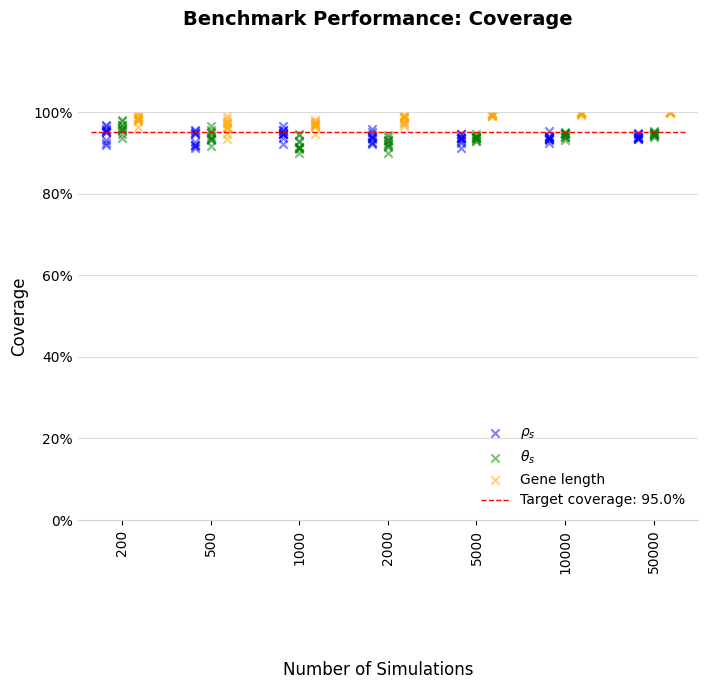

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: Coverage', fontsize=14, fontweight='bold', y=1.05)

results = stage0_marginal_coverage
x_base = np.arange(len(sim_budgets))
x = np.repeat(x_base, 10)
offsets = [-0.18, 0.0, 0.18]

y1 = results[0, :, :].flatten()
y2 = results[1, :, :].flatten()
y3 = results[2, :, :].flatten()

ax.scatter(x + offsets[0], y1, marker='x', color='blue', alpha=0.5, label=r'$\rho_s$')
ax.scatter(x + offsets[1], y2, marker='x', color='green', alpha=0.5, label=r'$\theta_s$')
ax.scatter(x + offsets[2], y3, marker='x', color='orange', alpha=0.5, label='Gene length')

ax.hlines(
    y=0.95,
    xmin=x_base[0] - 0.35,
    xmax=x_base[-1] + 0.35,
    color='red',
    linestyle='--',
    linewidth=1,
    label='Target coverage: 95.0%'
)

ax.set_xticks(x_base)
ax.set_xticklabels(sim_budgets, rotation=90)
ax.set_xlim(x_base[0] - 0.5, x_base[-1] + 0.5)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')

ax.tick_params(axis='y', length=0)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

ax.set_ylabel('Coverage', fontsize=12)
ax.legend(loc='lower right', fontsize=10, frameon=False)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.ylim(0, 1)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

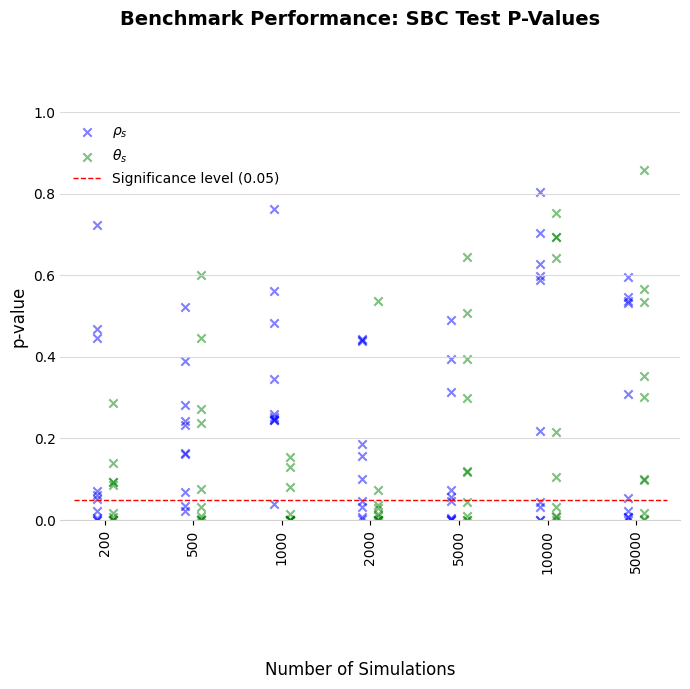

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: SBC Test P-Values', fontsize=14, fontweight='bold', y=1.05)

results = stage0_sbc_p_values
x_base = np.arange(len(sim_budgets))
x = np.repeat(x_base, 10)
offsets = [-0.09, 0.09]

y1 = results[0, :, :].flatten()
y2 = results[1, :, :].flatten()

ax.scatter(x + offsets[0], y1, marker='x', color='blue', alpha=0.5, label=r'$\rho_s$')
ax.scatter(x + offsets[1], y2, marker='x', color='green', alpha=0.5, label=r'$\theta_s$')

ax.hlines(
    y=0.05,
    xmin=x_base[0] - 0.35,
    xmax=x_base[-1] + 0.35,
    color='red',
    linestyle='--',
    linewidth=1,
    label='Significance level (0.05)'
)

ax.set_xticks(x_base)
ax.set_xticklabels(sim_budgets, rotation=90)
ax.set_xlim(x_base[0] - 0.5, x_base[-1] + 0.5)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')

ax.tick_params(axis='y', length=0)

ax.set_ylabel('p-value', fontsize=12)
ax.legend(loc='upper left', fontsize=10, frameon=False)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.ylim(0, 1)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

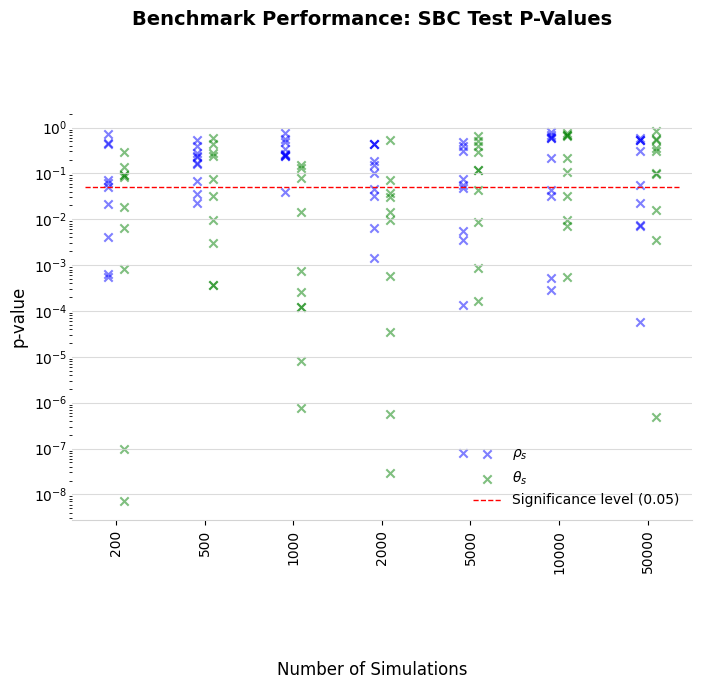

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: SBC Test P-Values', fontsize=14, fontweight='bold', y=1.05)

results = stage0_sbc_p_values
x_base = np.arange(len(sim_budgets))
x = np.repeat(x_base, 10)
offsets = [-0.09, 0.09]

y1 = results[0, :, :].flatten()
y2 = results[1, :, :].flatten()

ax.scatter(x + offsets[0], y1, marker='x', color='blue', alpha=0.5, label=r'$\rho_s$')
ax.scatter(x + offsets[1], y2, marker='x', color='green', alpha=0.5, label=r'$\theta_s$')

ax.hlines(
    y=0.05,
    xmin=x_base[0] - 0.35,
    xmax=x_base[-1] + 0.35,
    color='red',
    linestyle='--',
    linewidth=1,
    label='Significance level (0.05)'
)

ax.set_xticks(x_base)
ax.set_xticklabels(sim_budgets, rotation=90)
ax.set_xlim(x_base[0] - 0.5, x_base[-1] + 0.5)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')

ax.tick_params(axis='y', length=0)
ax.set_yscale('log')

ax.set_ylabel('p-value', fontsize=12)
ax.legend(loc='lower right', fontsize=10, frameon=False)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

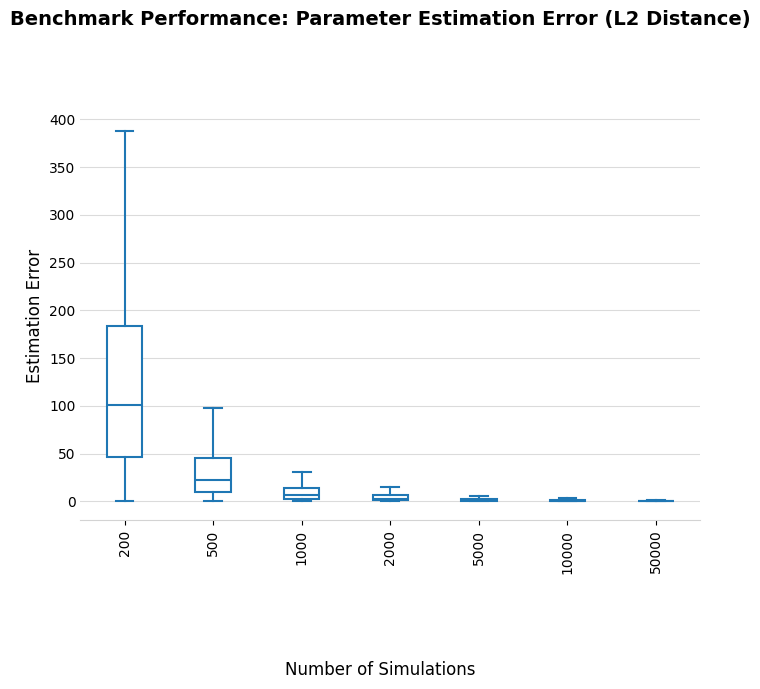

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Benchmark Performance: Parameter Estimation Error (L2 Distance)', fontsize=14, fontweight='bold', y=1.05)

raw_results = stage0_L2_error
x_positions = np.arange(len(sim_budgets))

arr = raw_results
arr_swapped = np.swapaxes(arr, 1, 2)
arr_flat = arr_swapped.reshape(-1, 7)

bplot = ax.boxplot(
    arr_flat,
    positions=x_positions,
    patch_artist=True,
    widths=0.4,
    showfliers=False
)

for patch in bplot['boxes']:
    patch.set_facecolor('white')
    patch.set_edgecolor('#1f77b4')
    patch.set_linewidth(1.5)
    
for element in ['whiskers', 'caps', 'medians']:
    for line in bplot[element]:
        line.set_color('#1f77b4')
        line.set_linewidth(1.5)

ax.set_xticks(x_positions)
ax.set_xticklabels(sim_budgets, rotation=90)

ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.tick_params(axis='y', length=0)

ax.set_ylabel(r'Estimation Error', fontsize=12)
fig.text(0.5, -0.05, 'Number of Simulations', ha='center', va='center', fontsize=12)
plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()

In [10]:
last_sim_p_values = stage0_sbc_p_values[:, -1, :]
last_sim_p_values.shape

(3, 10)

In [11]:
miscal_indices = np.where((last_sim_p_values[0, :] < 0.05) | (last_sim_p_values[1, :] < 0.05))[0]
miscal_indices

array([0, 2, 3, 4, 5, 8, 9])

In [12]:
def plot_sbc_ecdf_diff(ranks, num_posterior_samples, param_names=None):
    """
    Plots the ECDF Difference plot for SBC ranks.
    """
    ranks_np = np.array(ranks)
    num_sims, num_params = ranks_np.shape
    
    plt.figure(figsize=(10, 8))

    x_eval = np.linspace(0, 1, 1000)

    std_err = np.sqrt(x_eval * (1 - x_eval) / num_sims)
    envelope_upper = 1.96 * std_err
    envelope_lower = -1.96 * std_err

    plt.fill_between(x_eval, envelope_lower, envelope_upper, color='grey', alpha=0.3, label='95% Confidence')
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

    for i in range(num_params):
        param_ranks = ranks_np[:, i] / num_posterior_samples

        empirical_cdf = np.searchsorted(np.sort(param_ranks), x_eval, side='right') / num_sims

        diff = empirical_cdf - x_eval
        
        label = param_names[i] if param_names else f'Param {i}'
        plt.plot(x_eval, diff, label=label, linewidth=2)

    plt.title("SBC ECDF Difference Plot")
    plt.xlabel("Fractional Rank")
    plt.ylabel("Difference from Uniform CDF")
    plt.legend(frameon=False)
    plt.show()

Loaded posterior samples for seed 1 and n_sim 49948: shape (998, 500, 3)


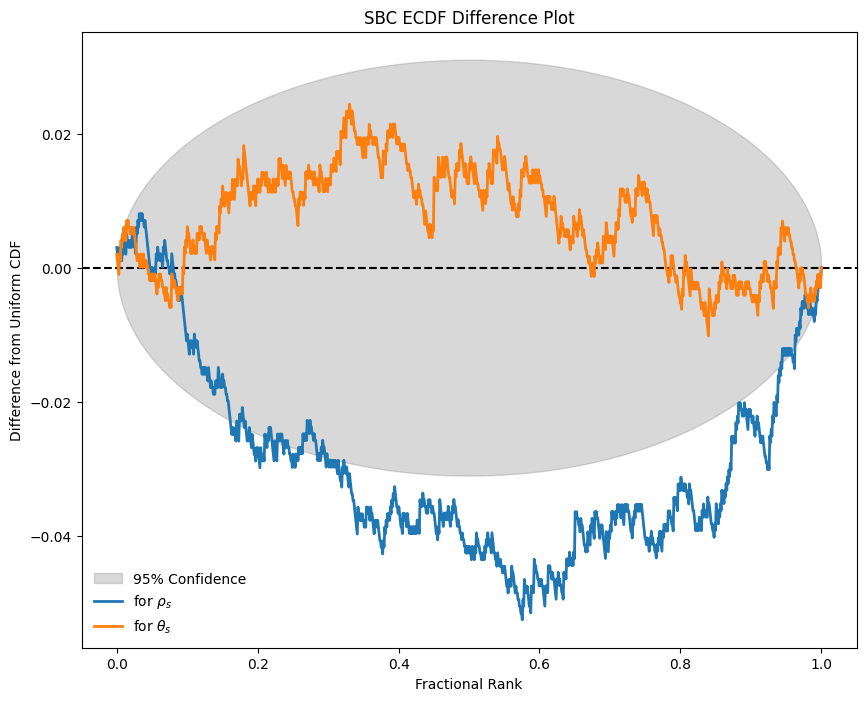

In [19]:
i = 0
seed = seeds[i]
n_sim = num_budgets[-1]
post_filename = f"../../data/post_diagnostic/npe_post_stage7_seed{seed}_sim{n_sim}.npy"
theta_est_post = np.load(post_filename)
print(f"Loaded posterior samples for seed {seed} and n_sim {n_sim}: shape {theta_est_post.shape}")

parameter_labels = [r"for $\rho_s$", r"for $\theta_s$", r"for L"]
theta_test_expanded = theta_test.unsqueeze(1)
theta_est_post_tensor = torch.tensor(theta_est_post, device=torch_device)
theta_est_post_tensor = theta_est_post_tensor.to(torch.float32)
is_less_than_truth = theta_est_post_tensor < theta_test_expanded
ranks = torch.sum(is_less_than_truth, dim=1)
plot_sbc_ecdf_diff(ranks.cpu().numpy()[:, :2], 500, param_names=parameter_labels[:2])

Loaded posterior samples for seed 1 and n_sim 49948: shape (998, 500, 3)


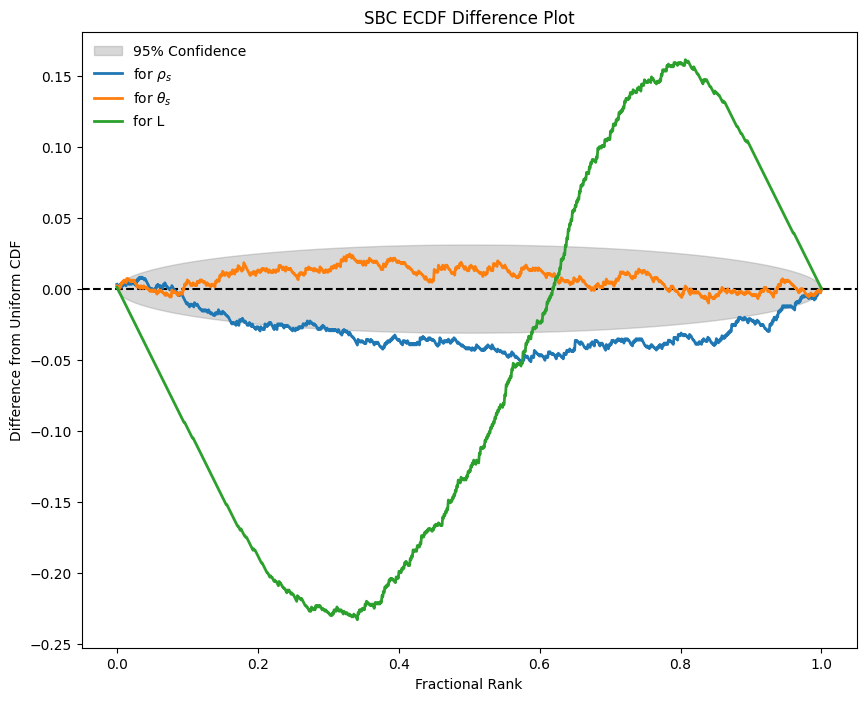

Loaded posterior samples for seed 3 and n_sim 49948: shape (998, 500, 3)


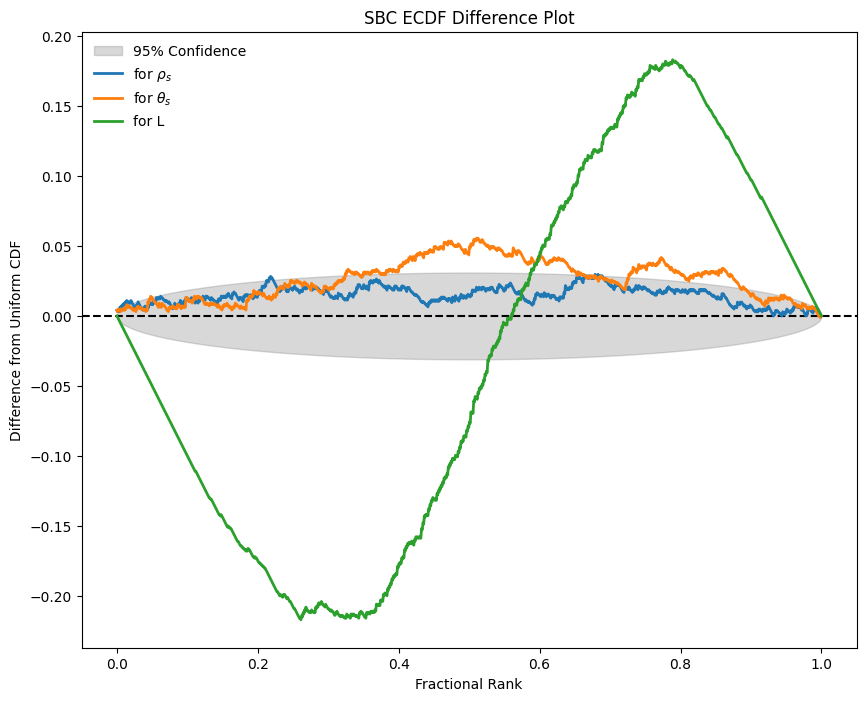

Loaded posterior samples for seed 4 and n_sim 49948: shape (998, 500, 3)


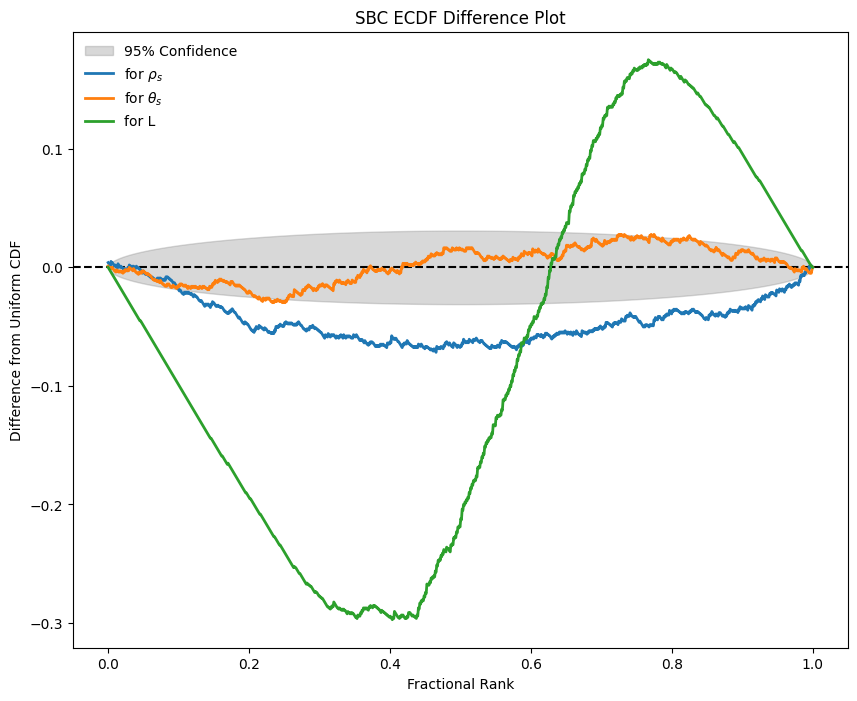

Loaded posterior samples for seed 5 and n_sim 49948: shape (998, 500, 3)


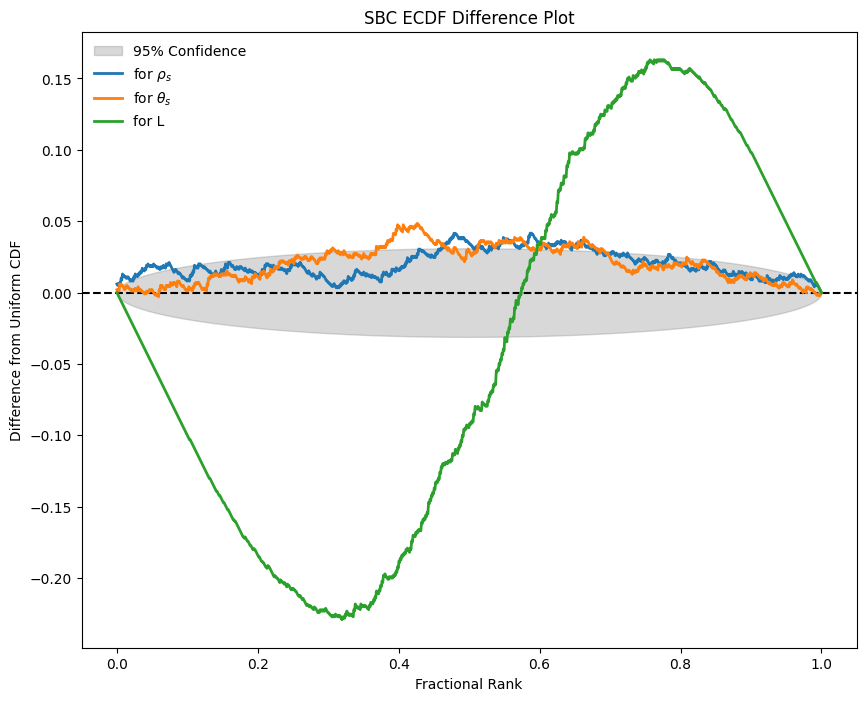

Loaded posterior samples for seed 6 and n_sim 49948: shape (998, 500, 3)


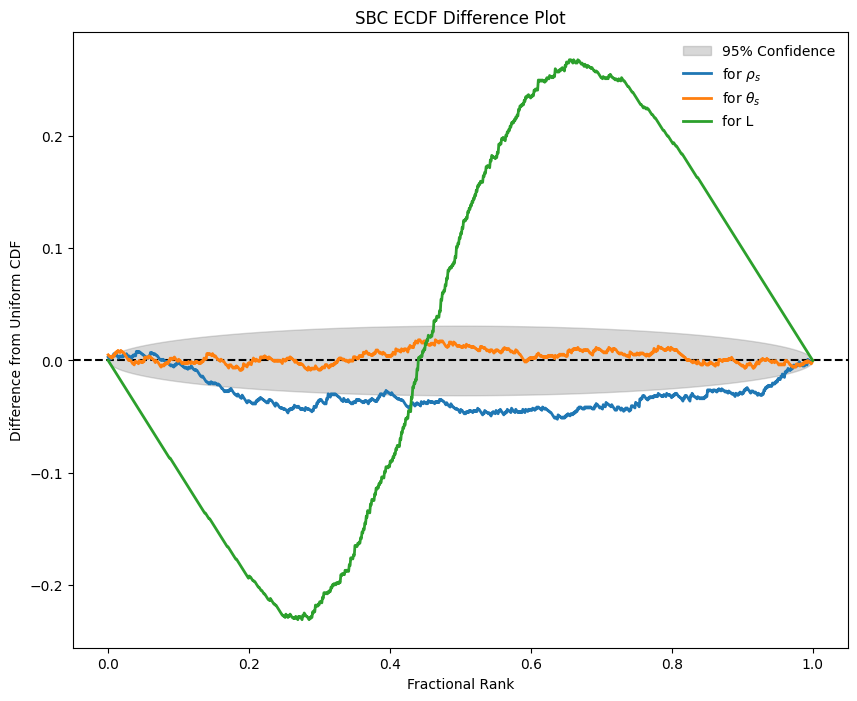

Loaded posterior samples for seed 9 and n_sim 49948: shape (998, 500, 3)


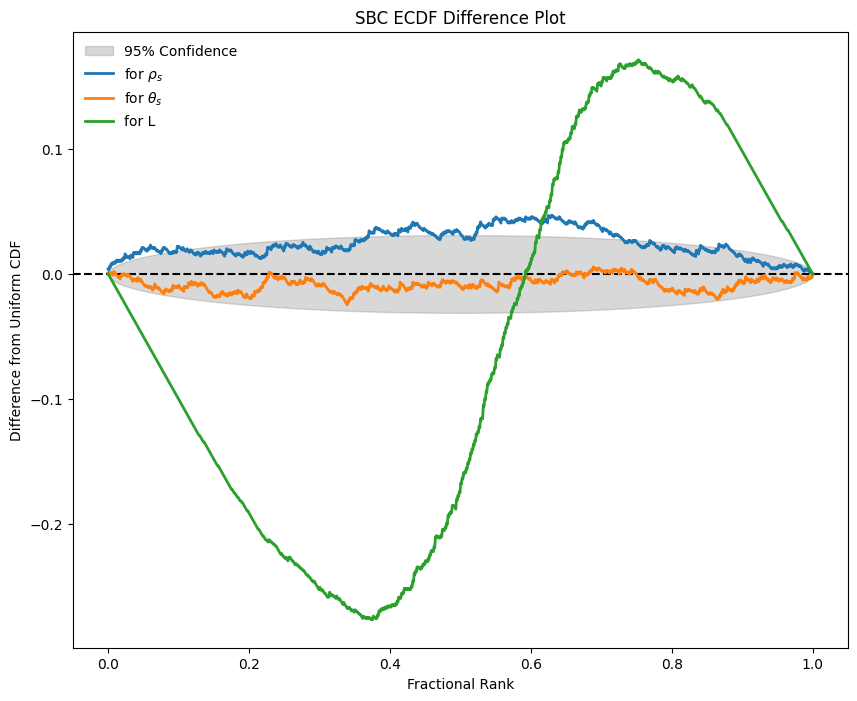

Loaded posterior samples for seed 10 and n_sim 49948: shape (998, 500, 3)


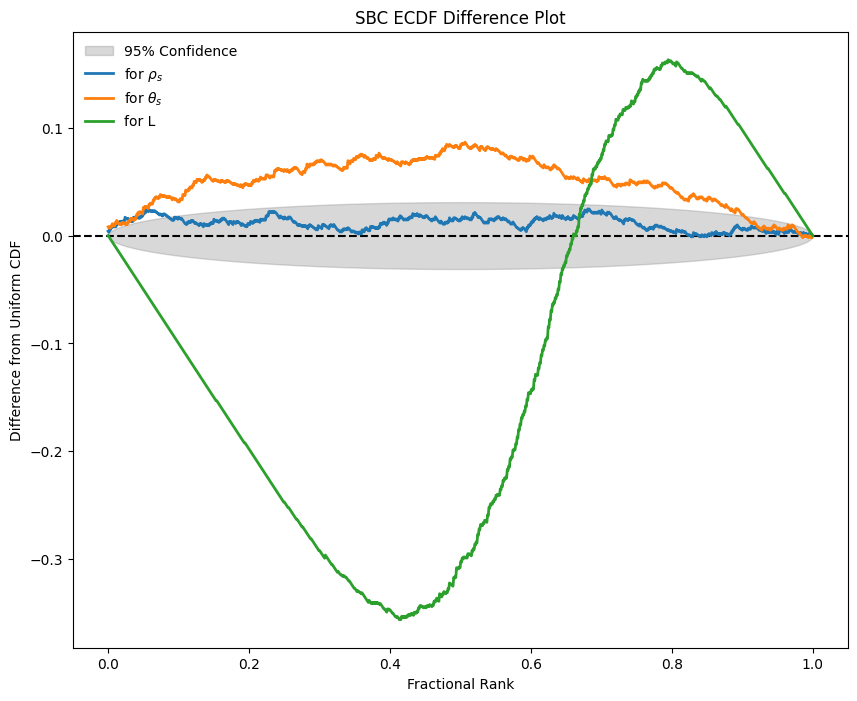

In [13]:
for i in miscal_indices:
    seed = seeds[i]
    n_sim = num_budgets[-1]
    post_filename = f"../../data/post_diagnostic/npe_post_stage7_seed{seed}_sim{n_sim}.npy"
    theta_est_post = np.load(post_filename)
    print(f"Loaded posterior samples for seed {seed} and n_sim {n_sim}: shape {theta_est_post.shape}")

    parameter_labels = [r"for $\rho_s$", r"for $\theta_s$", r"for L"]
    theta_test_expanded = theta_test.unsqueeze(1)
    theta_est_post_tensor = torch.tensor(theta_est_post, device=torch_device)
    theta_est_post_tensor = theta_est_post_tensor.to(torch.float32)
    is_less_than_truth = theta_est_post_tensor < theta_test_expanded
    ranks = torch.sum(is_less_than_truth, dim=1)
    plot_sbc_ecdf_diff(ranks.cpu().numpy(), 500, param_names=parameter_labels)